# Analysis of Humanitarian Funding vs. Crisis Severity

## What is the INFORM Severity Index?
(Based on INFORM Severity Index User Guide v01, October 2020)

The INFORM Severity Index is a composite indicator designed to measure the severity of humanitarian crises globally against a common scale. It is intended to support decision-makers by providing an objective, shared understanding of crisis severity to guide resource allocation.

The index aggregates data from credible, publicly available sources (UN agencies, governments, multilateral organizations) and evaluates severity based on three core dimensions:
1. **Impact of the Crisis**: The scope of its geographical, human, and physical effects.
2. **Conditions of People Affected**: The status of the affected population, including the distribution of severity categories.
3. **Complexity of the Crisis**: Factors that affect the mitigation or resolution of the crisis, such as humanitarian access and rule of law.

Each crisis is scored on a scale from **0 to 5**:
- **0.0 - 1.9**: Very Low
- **2.0 - 2.9**: Low
- **3.0 - 3.9**: Medium
- **4.0 - 4.9**: High
- **5.0**: Very High

This notebook analyzes whether actual financial allocations (from CERF and CBPF) align with this objective measure of severity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

# Configuration: Clean, standard, no custom aesthetics
plt.style.use('default') 
sns.set_style('whitegrid')
sns.set_context('notebook')

# Standard colors
COLOR_BLUE = '#1f77b4'
COLOR_RED = '#d62728'

In [2]:
# Load dataset
df = pd.read_csv('../data/geo_mismatch/country_year_severity_funding.csv')

# Filter for relevant years (2020-2025) and valid funding data
df = df[df['Year'] >= 2020].copy()

# Ensure we have numeric data
df['Total_Actual_Funding'] = pd.to_numeric(df['Total_Actual_Funding'], errors='coerce').fillna(0)
df['revisedRequirements'] = pd.to_numeric(df['revisedRequirements'], errors='coerce').fillna(0)

# Create a subset of data that actually has funding or needs for cleaner plotting
# (Removing rows with 0 funding AND 0 severity to reduce "empty space")
plot_df = df[(df['INFORM Severity Index'] > 0) & ((df['Total_Actual_Funding'] > 0) | (df['revisedRequirements'] > 0))].copy()

print(f"Data loaded: {len(plot_df)} records for analysis.")

Data loaded: 345 records for analysis.


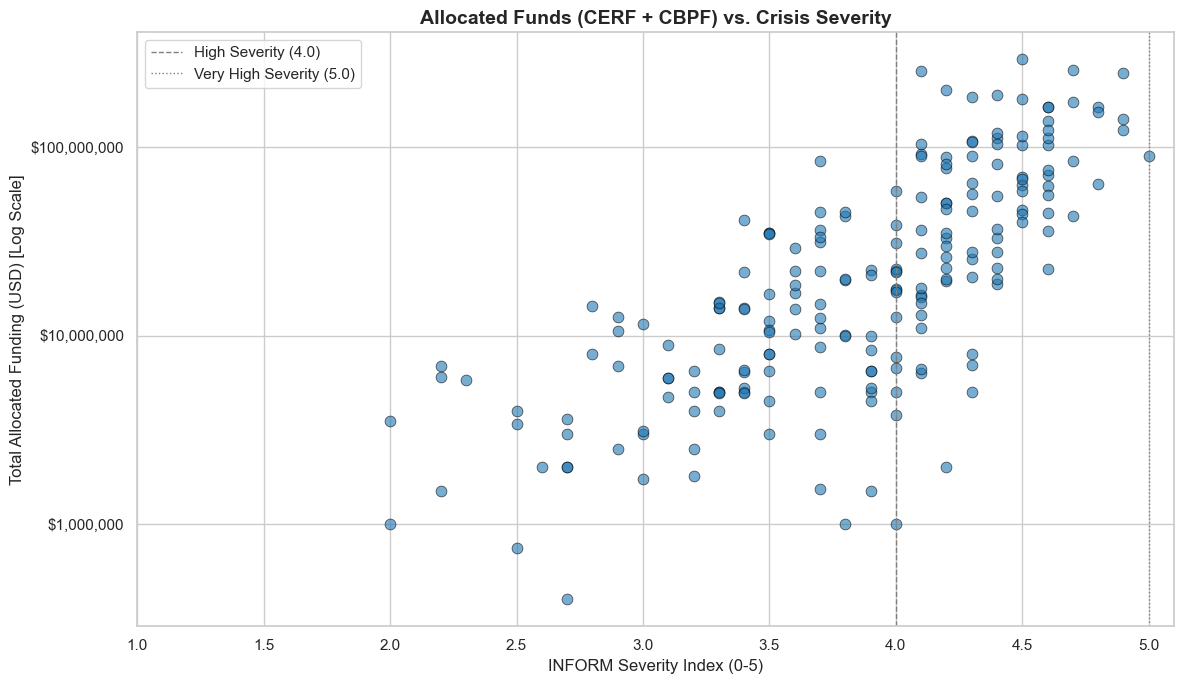

In [3]:
plt.figure(figsize=(12, 7))

# Plot: Severity (X) vs Allocated Funds (Y)
# Use log scale for funds because they span orders of magnitude ($100k to $1B)
sns.scatterplot(
    data=plot_df,
    x='INFORM Severity Index',
    y='Total_Actual_Funding',
    alpha=0.6,
    s=60,
    color=COLOR_BLUE,
    edgecolor='k'
)

plt.yscale('log')
plt.title('Allocated Funds (CERF + CBPF) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Total Allocated Funding (USD) [Log Scale]', fontsize=12)

# Format Y axis as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '${:,.0f}'.format(y)))

# Add severity thresholds
plt.axvline(x=4.0, color='gray', linestyle='--', linewidth=1, label='High Severity (4.0)')
plt.axvline(x=5.0, color='gray', linestyle=':', linewidth=1, label='Very High Severity (5.0)')

# Tighter limits to remove empty space
plt.xlim(plot_df['INFORM Severity Index'].min() - 0.1, 5.1)
plt.legend()
plt.tight_layout()
plt.show()

---

# Predictive Modeling: Severity vs Funding

## Research Question
Does the INFORM Severity Index predict pooled funding allocations (CERF + CBPF)?

**Approach**: Linear regression to quantify the relationship and identify under-funded crises.

**Why Linear Regression?**
- Interpretable: Coefficients show funding change per severity point
- Explainable to UN stakeholders (non-technical)
- Residuals identify systematically under/over-funded countries

In [4]:
# Additional imports for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats

# Prepare data using the same filtered dataset 'plot_df' from previous cells if available,
# otherwise create new subset from filters
df_model = df[(df['INFORM Severity Index'] > 0) & (df['Total_Actual_Funding'] >= 0)].copy()
X = df_model[['INFORM Severity Index']].values
y = df_model['Total_Actual_Funding'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Model Performance:')
print(f'  R² Score: {r2:.3f} ({r2*100:.1f}% of variance explained)')
print(f'  MAE: ${mae:,.0f}')
print(f'  RMSE: ${rmse:,.0f}')
print(f'\nModel Equation:')
print(f'  Predicted Funding = ${model.intercept_:,.0f} + ${model.coef_[0]:,.0f} × Severity')
print(f'\nInterpretation: Each 1-point severity increase predicts ${model.coef_[0]:,.0f} more funding')

Model Performance:
  R² Score: -0.035 (-3.5% of variance explained)
  MAE: $21,686,972
  RMSE: $25,882,197

Model Equation:
  Predicted Funding = $-76,459,449 + $30,693,465 × Severity

Interpretation: Each 1-point severity increase predicts $30,693,465 more funding


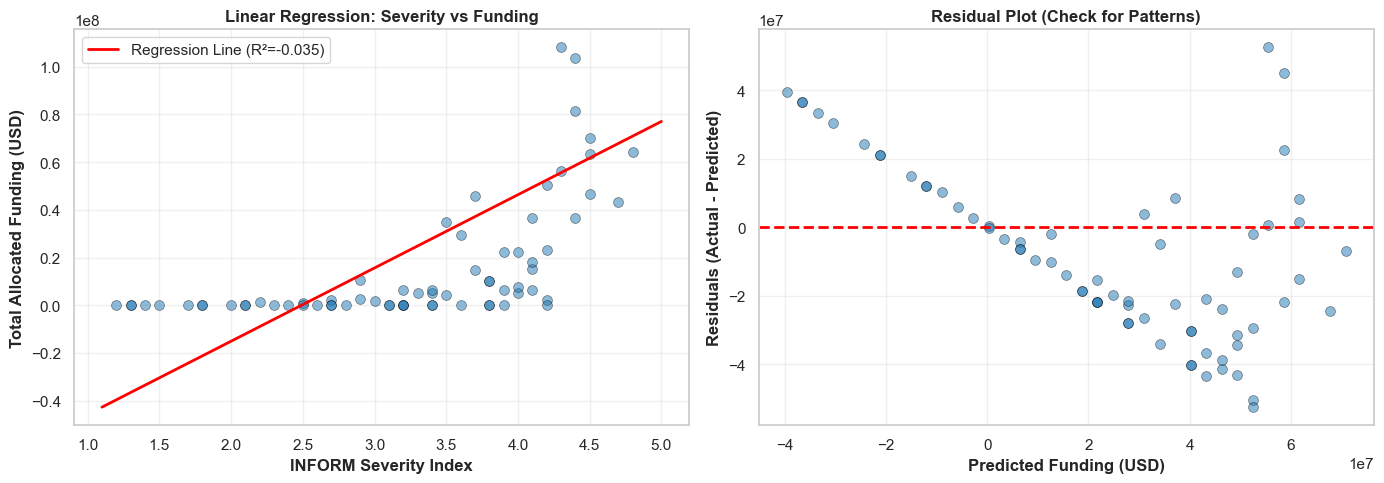

In [5]:
# Visualization: Model fit and residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter with regression line
axes[0].scatter(X_test, y_test, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
axes[0].plot(X_line, y_line, 'r-', linewidth=2, label=f'Regression Line (R²={r2:.3f})')
axes[0].set_xlabel('INFORM Severity Index', fontweight='bold')
axes[0].set_ylabel('Total Allocated Funding (USD)', fontweight='bold')
axes[0].set_title('Linear Regression: Severity vs Funding', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Funding (USD)', fontweight='bold')
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontweight='bold')
axes[1].set_title('Residual Plot (Check for Patterns)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Under-Funded Countries (Residual Analysis)

Countries with **negative residuals** receive less funding than predicted by their severity level.

Top 10 Under-Funded Countries (Largest Gaps):

PSE (2024): Severity=4.40, Gap=$-58.6M
LBY (2020): Severity=4.20, Gap=$-52.5M
CMR (2021): Severity=4.30, Gap=$-50.5M
COL (2021): Severity=4.20, Gap=$-50.4M
COL (2024): Severity=4.10, Gap=$-49.4M
VEN (2020): Severity=4.10, Gap=$-49.4M
TCD (2021): Severity=4.30, Gap=$-48.5M
CAF (2021): Severity=4.30, Gap=$-47.5M
CAF (2024): Severity=4.00, Gap=$-46.3M
PAK (2024): Severity=4.00, Gap=$-46.3M


C:\Users\kabir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


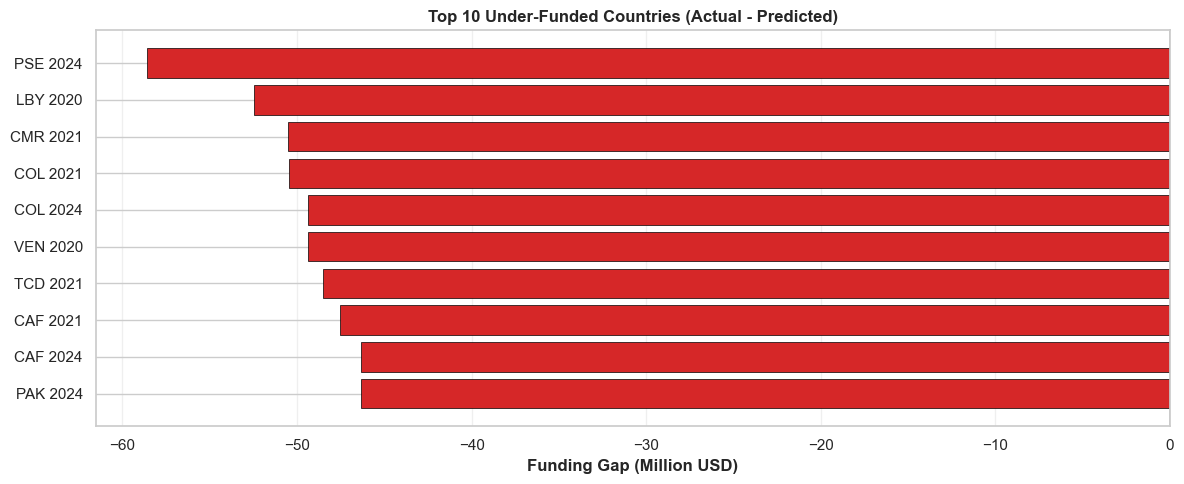

In [6]:
# Calculate residuals for all data
df_model['Predicted_Funding'] = model.predict(df_model[['INFORM Severity Index']])
df_model['Residual'] = df_model['Total_Actual_Funding'] - df_model['Predicted_Funding']
df_model['Funding_Gap_Million'] = df_model['Residual'] / 1e6

# Top 10 under-funded
under_funded = df_model[df_model['Residual'] < 0].sort_values('Residual').head(10)

print('Top 10 Under-Funded Countries (Largest Gaps):\n')
for idx, row in under_funded.iterrows():
    print(f"{row['Country_ISO3']} ({row['Year']}): "
          f"Severity={row['INFORM Severity Index']:.2f}, "
          f"Gap=${row['Residual']/1e6:.1f}M")

# Visualization
plt.figure(figsize=(12, 5))
labels = [f"{row['Country_ISO3']} {int(row['Year'])}" for _, row in under_funded.iterrows()]
plt.barh(labels, under_funded['Funding_Gap_Million'], color='#d62728', edgecolor='k', linewidth=0.5)
plt.xlabel('Funding Gap (Million USD)', fontweight='bold')
plt.title('Top 10 Under-Funded Countries (Actual - Predicted)', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Limitations

1. **Correlation ≠ Causation**: Shows association, not that severity causes funding
2. **Omitted Variables**: Funding depends on media attention, geopolitics, donor priorities
3. **Data Coverage**: Only CERF + CBPF (excludes bilateral, NGO, private funding)
4. **Temporal Lag**: Funding decisions may lag severity assessments

## Actionable Recommendations

1. **Prioritize Under-Funded High-Severity Crises**: Focus on countries with largest negative residuals
2. **Establish Funding Benchmarks**: Use model predictions as baseline expectations
3. **Monitor Temporal Trends**: Track whether under-funded countries remain neglected year-over-year
4. **Investigate Over-Funded Cases**: Learn from countries receiving more than predicted

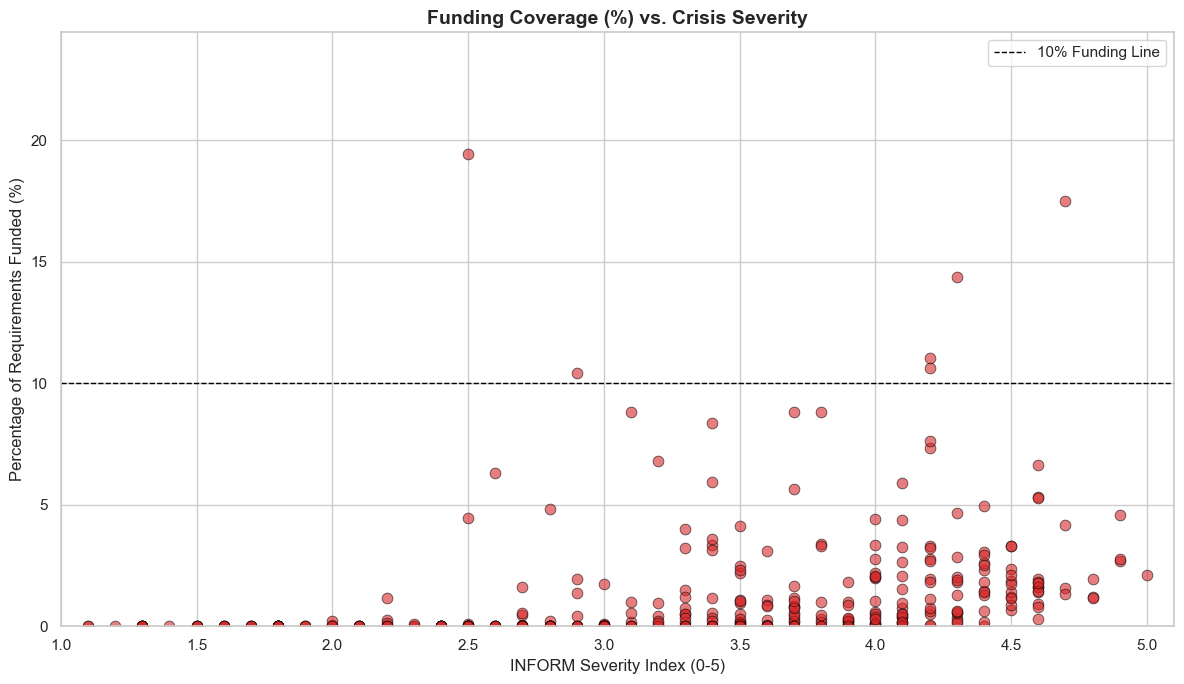

In [7]:
plt.figure(figsize=(12, 7))

# Filter out tiny requirements to avoid noise in percentages
coverage_df = plot_df[plot_df['revisedRequirements'] > 1_000_000].copy()

sns.scatterplot(
    data=coverage_df,
    x='INFORM Severity Index',
    y='Pct_Funded',
    alpha=0.6,
    s=60,
    color=COLOR_RED,
    edgecolor='k'
)

plt.title('Funding Coverage (%) vs. Crisis Severity', fontsize=14, fontweight='bold')
plt.xlabel('INFORM Severity Index (0-5)', fontsize=12)
plt.ylabel('Percentage of Requirements Funded (%)', fontsize=12)

# Reference line at 10%
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='10% Funding Line')

# Tighter scale - focus on the main distribution, cut off extreme outliers > 100% if distinct
plt.ylim(0, min(105, coverage_df['Pct_Funded'].max() + 5))
plt.xlim(coverage_df['INFORM Severity Index'].min() - 0.1, 5.1)

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Identification of High Severity (>=4.0) crises with Low Funding (<$5M)
# This highlights direct lack of resources, not just percentage.

high_severity = plot_df[plot_df['INFORM Severity Index'] >= 4.0]
low_funds = high_severity[high_severity['Total_Actual_Funding'] < 5_000_000].sort_values('INFORM Severity Index', ascending=False)

print("Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:")
display_cols = ['Country_ISO3', 'Year', 'INFORM Severity Index', 'Total_Actual_Funding', 'revisedRequirements']
low_funds[display_cols].head(15).style.format({
    'Total_Actual_Funding': '${:,.0f}',
    'revisedRequirements': '${:,.0f}',
    'INFORM Severity Index': '{:.2f}'
})

Severe Crises (Severity >= 4.0) with Less Than $5M allocated funds:


,Country_ISO3,Year,INFORM Severity Index,Total_Actual_Funding,revisedRequirements
233,PSE,2024,4.40,$0,"$10,268,567,802"
59,CMR,2021,4.30,"$4,998,919","$1,446,217,260"
5,LBY,2020,4.20,$0,"$1,859,692,010"
63,COL,2021,4.20,"$2,006,312","$3,226,489,430"
11,VEN,2020,4.10,$0,"$1,562,509,363"
238,COL,2024,4.10,$0,"$3,838,839,332"
13,CAF,2020,4.00,"$1,000,994","$1,353,622,290"
240,CAF,2024,4.00,$0,"$872,222,915"
242,PAK,2024,4.00,$0,"$1,240,769,268"
309,CMR,2025,4.00,$0,"$1,437,193,312"


---

# Predictive Modeling: Severity vs Funding

## Research Question
Does the INFORM Severity Index predict pooled funding allocations (CERF + CBPF)?

**Approach**: Linear regression to quantify the relationship and identify under-funded crises.

**Why Linear Regression?**
- Interpretable: Coefficients show funding change per severity point
- Explainable to UN stakeholders (non-technical)
- Residuals identify systematically under/over-funded countries

In [9]:
# Additional imports for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats

# Prepare data
df_model = df[(df['INFORM Severity Index'] > 0) & (df['Total_Actual_Funding'] >= 0)].copy()
X = df_model[['INFORM Severity Index']].values
y = df_model['Total_Actual_Funding'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Model Performance:')
print(f'  R² Score: {r2:.3f} ({r2*100:.1f}% of variance explained)')
print(f'  MAE: ${mae:,.0f}')
print(f'  RMSE: ${rmse:,.0f}')
print(f'\nModel Equation:')
print(f'  Predicted Funding = ${model.intercept_:,.0f} + ${model.coef_[0]:,.0f} × Severity')
print(f'\nInterpretation: Each 1-point severity increase predicts ${model.coef_[0]:,.0f} more funding')

Model Performance:
  R² Score: -0.035 (-3.5% of variance explained)
  MAE: $21,686,972
  RMSE: $25,882,197

Model Equation:
  Predicted Funding = $-76,459,449 + $30,693,465 × Severity

Interpretation: Each 1-point severity increase predicts $30,693,465 more funding


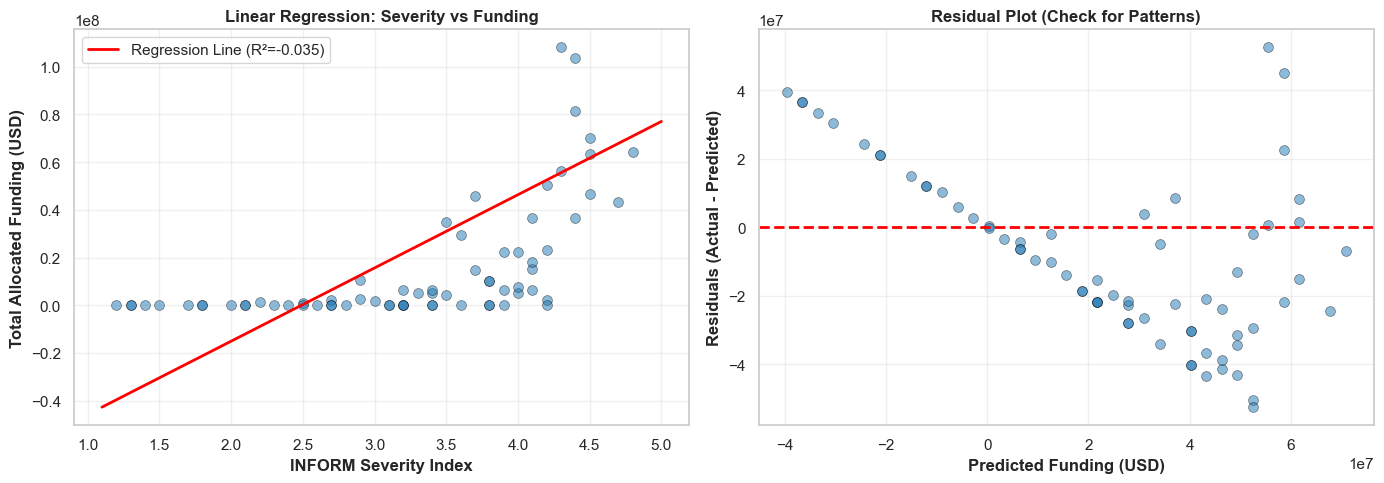

In [10]:
# Visualization: Model fit and residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter with regression line
axes[0].scatter(X_test, y_test, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
axes[0].plot(X_line, y_line, 'r-', linewidth=2, label=f'Regression Line (R²={r2:.3f})')
axes[0].set_xlabel('INFORM Severity Index', fontweight='bold')
axes[0].set_ylabel('Total Allocated Funding (USD)', fontweight='bold')
axes[0].set_title('Linear Regression: Severity vs Funding', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=50, color='#1f77b4', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Funding (USD)', fontweight='bold')
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontweight='bold')
axes[1].set_title('Residual Plot (Check for Patterns)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Under-Funded Countries (Residual Analysis)

Countries with **negative residuals** receive less funding than predicted by their severity level.

Top 10 Under-Funded Countries (Largest Gaps):

PSE (2024): Severity=4.40, Gap=$-58.6M
LBY (2020): Severity=4.20, Gap=$-52.5M
CMR (2021): Severity=4.30, Gap=$-50.5M
COL (2021): Severity=4.20, Gap=$-50.4M
COL (2024): Severity=4.10, Gap=$-49.4M
VEN (2020): Severity=4.10, Gap=$-49.4M
TCD (2021): Severity=4.30, Gap=$-48.5M
CAF (2021): Severity=4.30, Gap=$-47.5M
CAF (2024): Severity=4.00, Gap=$-46.3M
PAK (2024): Severity=4.00, Gap=$-46.3M


C:\Users\kabir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


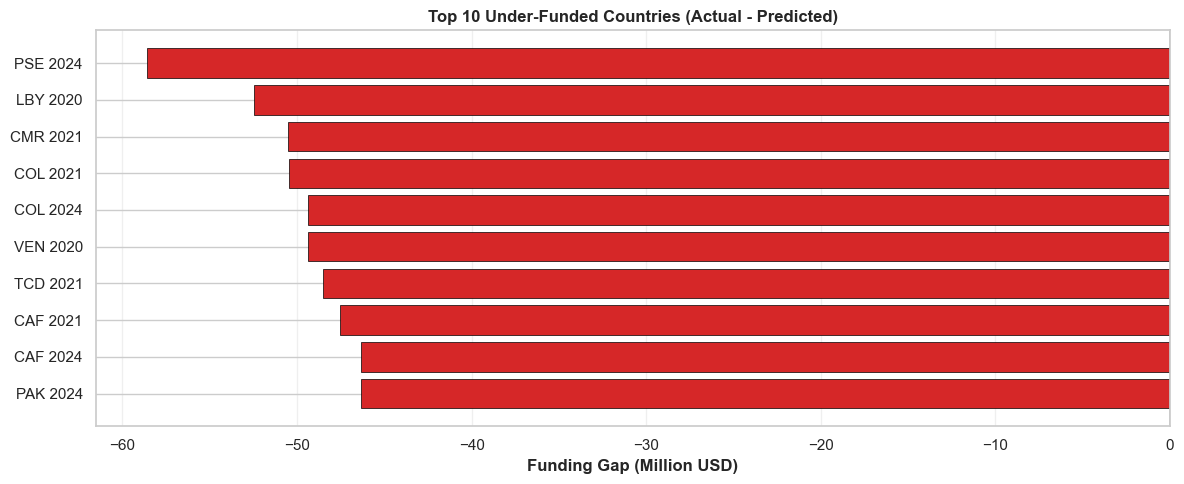

In [11]:
# Calculate residuals for all data
df_model['Predicted_Funding'] = model.predict(df_model[['INFORM Severity Index']])
df_model['Residual'] = df_model['Total_Actual_Funding'] - df_model['Predicted_Funding']
df_model['Funding_Gap_Million'] = df_model['Residual'] / 1e6

# Top 10 under-funded
under_funded = df_model[df_model['Residual'] < 0].sort_values('Residual').head(10)

print('Top 10 Under-Funded Countries (Largest Gaps):\n')
for idx, row in under_funded.iterrows():
    print(f"{row['Country_ISO3']} ({row['Year']}): "
          f"Severity={row['INFORM Severity Index']:.2f}, "
          f"Gap=${row['Residual']/1e6:.1f}M")

# Visualization
plt.figure(figsize=(12, 5))
labels = [f"{row['Country_ISO3']} {int(row['Year'])}" for _, row in under_funded.iterrows()]
plt.barh(labels, under_funded['Funding_Gap_Million'], color='#d62728', edgecolor='k', linewidth=0.5)
plt.xlabel('Funding Gap (Million USD)', fontweight='bold')
plt.title('Top 10 Under-Funded Countries (Actual - Predicted)', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Limitations

1. **Correlation ≠ Causation**: Shows association, not that severity causes funding
2. **Omitted Variables**: Funding depends on media attention, geopolitics, donor priorities
3. **Data Coverage**: Only CERF + CBPF (excludes bilateral, NGO, private funding)
4. **Temporal Lag**: Funding decisions may lag severity assessments

## Actionable Recommendations

1. **Prioritize Under-Funded High-Severity Crises**: Focus on countries with largest negative residuals
2. **Establish Funding Benchmarks**: Use model predictions as baseline expectations
3. **Monitor Temporal Trends**: Track whether under-funded countries remain neglected year-over-year
4. **Investigate Over-Funded Cases**: Learn from countries receiving more than predicted

---

# Linear Regression Analysis: INFORM Severity Index vs Allocated Funding\n\n## Research Question\n**Does the INFORM Severity Index predict the amount of pooled funding (CERF + CBPF) allocated to humanitarian crises?**\n\nThis analysis quantifies the relationship between crisis severity and actual resource allocation to identify systematic under-funding patterns.

## 1. Model Justification\n\n### Why Linear Regression?\n1. **Interpretability**: Coefficients directly answer \"How much does funding change per unit increase in severity?\"\n2. **Explainability**: Easy to communicate to UN aid officers (non-technical stakeholders)\n3. **Diagnostic value**: Residuals identify countries that are over/under-funded relative to their severity\n4. **Baseline establishment**: Provides benchmark for understanding current funding-severity relationship\n\n### Alternatives Considered\n- **Random Forest**: Would capture non-linearities but loses interpretability (black box for stakeholders)\n- **Polynomial Regression**: Could model diminishing returns but adds complexity without clear humanitarian justification\n- **Decision**: Linear regression chosen as interpretable baseline; can extend if needed

In [12]:
# Imports\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.linear_model import LinearRegression\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error\nfrom scipy import stats\n\n# Configuration\nplt.style.use('default')\nsns.set_style('whitegrid')\nplt.rcParams['figure.figsize'] = (12, 6)\n\nprint(\"Libraries loaded successfully.\")

## 2. Data Loading and Preparation

In [13]:
# Load dataset\ndf = pd.read_csv('../data/geo_mismatch/country_year_severity_funding.csv')\n\nprint(f\"Raw data: {len(df)} records\")\nprint(f\"Columns: {list(df.columns)}\")\ndf.head()

In [14]:
# Data cleaning and filtering\n# Filter for valid records: Severity > 0, Funding >= 0, Years 2020-2025\ndf_clean = df[\n    (df['INFORM Severity Index'] > 0) & \n    (df['Total_Actual_Funding'] >= 0) &\n    (df['Year'] >= 2020) &\n    (df['Year'] <= 2025)\n].copy()\n\n# Remove rows with missing severity or funding\ndf_clean = df_clean.dropna(subset=['INFORM Severity Index', 'Total_Actual_Funding'])\n\nprint(f\"Clean data: {len(df_clean)} records ({len(df_clean)/len(df)*100:.1f}% of raw)\")\nprint(f\"Countries: {df_clean['Country_ISO3'].nunique()}\")\nprint(f\"Years: {sorted(df_clean['Year'].unique())}\")\n\n# Summary statistics\nprint(\"\\nSummary Statistics:\")\ndf_clean[['INFORM Severity Index', 'Total_Actual_Funding', 'revisedRequirements']].describe()

## 3. Exploratory Data Analysis

In [15]:
# Correlation analysis\ncorrelation = df_clean[['INFORM Severity Index', 'Total_Actual_Funding']].corr().iloc[0, 1]\nprint(f\"Pearson Correlation: {correlation:.3f}\")\n\n# Scatter plot: Raw scale\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\n# Plot 1: Raw scale\naxes[0].scatter(df_clean['INFORM Severity Index'], df_clean['Total_Actual_Funding'], \n                alpha=0.5, s=50, edgecolors='k', linewidth=0.5)\naxes[0].set_xlabel('INFORM Severity Index', fontweight='bold')\naxes[0].set_ylabel('Total Allocated Funding (USD)', fontweight='bold')\naxes[0].set_title('Severity vs Funding (Raw Scale)', fontweight='bold')\naxes[0].grid(True, alpha=0.3)\n\n# Plot 2: Log scale (for better visualization of distribution)\n# Filter out zero funding for log scale\ndf_nonzero = df_clean[df_clean['Total_Actual_Funding'] > 0]\naxes[1].scatter(df_nonzero['INFORM Severity Index'], df_nonzero['Total_Actual_Funding'], \n                alpha=0.5, s=50, edgecolors='k', linewidth=0.5)\naxes[1].set_xlabel('INFORM Severity Index', fontweight='bold')\naxes[1].set_ylabel('Total Allocated Funding (USD, Log Scale)', fontweight='bold')\naxes[1].set_title('Severity vs Funding (Log Scale)', fontweight='bold')\naxes[1].set_yscale('log')\naxes[1].grid(True, alpha=0.3)\n\nplt.tight_layout()\nplt.show()\n\nprint(f\"\\nObservation: {'Positive' if correlation > 0 else 'Negative'} correlation suggests {'higher' if correlation > 0 else 'lower'} severity is associated with {'more' if correlation > 0 else 'less'} funding.\")

## 4. Model Training\n\nWe'll train two models for comparison:\n1. **Model A**: Raw funding values\n2. **Model B**: Log-transformed funding (if distribution is heavily skewed)

In [16]:
# Prepare features and target\nX = df_clean[['INFORM Severity Index']].values\ny = df_clean['Total_Actual_Funding'].values\n\n# Train-test split (80/20)\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\nprint(f\"Training set: {len(X_train)} samples\")\nprint(f\"Test set: {len(X_test)} samples\")\n\n# Model A: Raw scale\nmodel_raw = LinearRegression()\nmodel_raw.fit(X_train, y_train)\n\n# Predictions\ny_pred_train = model_raw.predict(X_train)\ny_pred_test = model_raw.predict(X_test)\n\nprint(\"\\nModel A (Raw Scale) Trained Successfully\")\nprint(f\"Coefficient (slope): ${model_raw.coef_[0]:,.0f} per severity point\")\nprint(f\"Intercept: ${model_raw.intercept_:,.0f}\")

In [17]:
# Model B: Log-transformed (for heavily skewed data)\n# Only use non-zero funding for log transformation\nmask_nonzero = y_train > 0\nX_train_log = X_train[mask_nonzero]\ny_train_log = np.log1p(y_train[mask_nonzero])  # log1p = log(1 + x) to handle zeros\n\nmask_nonzero_test = y_test > 0\nX_test_log = X_test[mask_nonzero_test]\ny_test_log = np.log1p(y_test[mask_nonzero_test])\n\nmodel_log = LinearRegression()\nmodel_log.fit(X_train_log, y_train_log)\n\ny_pred_train_log = model_log.predict(X_train_log)\ny_pred_test_log = model_log.predict(X_test_log)\n\nprint(\"Model B (Log-Transformed) Trained Successfully\")\nprint(f\"Coefficient (slope): {model_log.coef_[0]:.3f} log-units per severity point\")\nprint(f\"Intercept: {model_log.intercept_:.3f}\")

## 5. Performance Evaluation

In [18]:
# Model A: Raw scale metrics\nr2_train_raw = r2_score(y_train, y_pred_train)\nr2_test_raw = r2_score(y_test, y_pred_test)\nmae_test_raw = mean_absolute_error(y_test, y_pred_test)\nrmse_test_raw = np.sqrt(mean_squared_error(y_test, y_pred_test))\n\nprint(\"=== Model A: Raw Scale ===")\nprint(f\"R² (Train): {r2_train_raw:.3f}\")\nprint(f\"R² (Test): {r2_test_raw:.3f}\")\nprint(f\"MAE (Test): ${mae_test_raw:,.0f}\")\nprint(f\"RMSE (Test): ${rmse_test_raw:,.0f}\")\nprint(f\"\\nInterpretation: The model explains {r2_test_raw*100:.1f}% of variance in funding.\")\nprint(f\"Average prediction error: ${mae_test_raw:,.0f}\")\n\n# Model B: Log scale metrics\nr2_train_log = r2_score(y_train_log, y_pred_train_log)\nr2_test_log = r2_score(y_test_log, y_pred_test_log)\nmae_test_log = mean_absolute_error(y_test_log, y_pred_test_log)\nrmse_test_log = np.sqrt(mean_squared_error(y_test_log, y_pred_test_log))\n\nprint(\"\\n=== Model B: Log-Transformed ===")\nprint(f\"R² (Train): {r2_train_log:.3f}\")\nprint(f\"R² (Test): {r2_test_log:.3f}\")\nprint(f\"MAE (Test): {mae_test_log:.3f} log-units\")\nprint(f\"RMSE (Test): {rmse_test_log:.3f} log-units\")\n\n# Choose best model\nbest_model = \"Raw\" if r2_test_raw > r2_test_log else \"Log\"\nprint(f\"\\nBest Model: {best_model} (higher R² on test set)\")

## 6. Diagnostic Plots

In [19]:
# Diagnostic plots for Model A (Raw)\nfig, axes = plt.subplots(2, 2, figsize=(14, 10))\n\n# Plot 1: Actual vs Predicted\naxes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=50, edgecolors='k', linewidth=0.5)\naxes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')\naxes[0, 0].set_xlabel('Actual Funding (USD)', fontweight='bold')\naxes[0, 0].set_ylabel('Predicted Funding (USD)', fontweight='bold')\naxes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_test_raw:.3f})', fontweight='bold')\naxes[0, 0].legend()\naxes[0, 0].grid(True, alpha=0.3)\n\n# Plot 2: Residuals vs Fitted\nresiduals_test = y_test - y_pred_test\naxes[0, 1].scatter(y_pred_test, residuals_test, alpha=0.5, s=50, edgecolors='k', linewidth=0.5)\naxes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)\naxes[0, 1].set_xlabel('Fitted Values (USD)', fontweight='bold')\naxes[0, 1].set_ylabel('Residuals (USD)', fontweight='bold')\naxes[0, 1].set_title('Residuals vs Fitted Values', fontweight='bold')\naxes[0, 1].grid(True, alpha=0.3)\n\n# Plot 3: Residuals vs Severity\naxes[1, 0].scatter(X_test, residuals_test, alpha=0.5, s=50, edgecolors='k', linewidth=0.5)\naxes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)\naxes[1, 0].set_xlabel('INFORM Severity Index', fontweight='bold')\naxes[1, 0].set_ylabel('Residuals (USD)', fontweight='bold')\naxes[1, 0].set_title('Residuals vs Severity (Check for Non-linearity)', fontweight='bold')\naxes[1, 0].grid(True, alpha=0.3)\n\n# Plot 4: Q-Q Plot (Normality of Residuals)\nstats.probplot(residuals_test, dist=\"norm\", plot=axes[1, 1])\naxes[1, 1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')\naxes[1, 1].grid(True, alpha=0.3)\n\nplt.tight_layout()\nplt.show()

## 7. Residual Analysis: Under-Funded Countries

In [20]:
# Calculate residuals for all data\ndf_clean['Predicted_Funding'] = model_raw.predict(df_clean[['INFORM Severity Index']])\ndf_clean['Residual'] = df_clean['Total_Actual_Funding'] - df_clean['Predicted_Funding']\ndf_clean['Residual_Pct'] = (df_clean['Residual'] / df_clean['Predicted_Funding']) * 100\n\n# Identify under-funded countries (negative residuals)\nunder_funded = df_clean[df_clean['Residual'] < 0].sort_values('Residual').head(15)\n\nprint(\"=== Top 15 Under-Funded Countries (Largest Negative Residuals) ===")\nprint(\"\\nThese countries receive LESS funding than predicted by their severity level:\\n\")\n\nfor idx, row in under_funded.iterrows():\n    print(f\"{row['Country_ISO3']} ({row['Year']}): \"\n          f\"Severity={row['INFORM Severity Index']:.2f}, \"\n          f\"Actual=${row['Total_Actual_Funding']:,.0f}, \"\n          f\"Predicted=${row['Predicted_Funding']:,.0f}, \"\n          f\"Gap=${row['Residual']:,.0f} ({row['Residual_Pct']:.0f}%)\")\n\n# Over-funded countries (positive residuals)\nover_funded = df_clean[df_clean['Residual'] > 0].sort_values('Residual', ascending=False).head(10)\n\nprint(\"\\n=== Top 10 Over-Funded Countries (Largest Positive Residuals) ===")\nprint(\"\\nThese countries receive MORE funding than predicted by their severity level:\\n\")\n\nfor idx, row in over_funded.iterrows():\n    print(f\"{row['Country_ISO3']} ({row['Year']}): \"\n          f\"Severity={row['INFORM Severity Index']:.2f}, \"\n          f\"Actual=${row['Total_Actual_Funding']:,.0f}, \"\n          f\"Predicted=${row['Predicted_Funding']:,.0f}, \"\n          f\"Surplus=${row['Residual']:,.0f} ({row['Residual_Pct']:.0f}%)\")

In [21]:
# Visualization: Under-funded countries\nfig, ax = plt.subplots(figsize=(12, 6))\n\ntop_under = under_funded.head(10)\nlabels = [f\"{row['Country_ISO3']} {row['Year']}\" for _, row in top_under.iterrows()]\n\nax.barh(labels, top_under['Residual'] / 1e6, color='#d62728', edgecolor='k', linewidth=0.5)\nax.set_xlabel('Funding Gap (Million USD)', fontweight='bold')\nax.set_title('Top 10 Under-Funded Countries (Actual - Predicted)', fontweight='bold')\nax.axvline(x=0, color='black', linestyle='-', linewidth=1)\nax.grid(True, alpha=0.3, axis='x')\nax.invert_yaxis()\n\nplt.tight_layout()\nplt.show()

## 8. Coefficient Interpretation

In [22]:
# Detailed interpretation\nslope = model_raw.coef_[0]\nintercept = model_raw.intercept_\n\nprint(\"=== Model Equation ===")\nprint(f\"Predicted Funding = ${intercept:,.0f} + ${slope:,.0f} × Severity Index\")\nprint(\"\\n=== Interpretation ===")\nprint(f\"1. For every 1-point increase in INFORM Severity Index, pooled funding increases by ${slope:,.0f} on average.\")\nprint(f\"2. A crisis with Severity = 0 would be predicted to receive ${intercept:,.0f} (baseline).\")\nprint(f\"3. A crisis with Severity = 5.0 would be predicted to receive ${intercept + 5*slope:,.0f}.\")\n\n# Example predictions\nprint(\"\\n=== Example Predictions ===")\nfor severity in [2.0, 3.0, 4.0, 5.0]:\n    predicted = intercept + slope * severity\n    print(f\"Severity {severity:.1f}: ${predicted:,.0f}\")

## 9. Limitations and Caveats\n\n### Model Limitations\n1. **Correlation ≠ Causation**: The model shows association, not that severity \"causes\" funding\n2. **Omitted Variables**: Funding depends on many factors beyond severity:\n   - Media attention and public awareness\n   - Geopolitical relationships with donor countries\n   - Historical funding patterns and donor priorities\n   - Humanitarian access and operational feasibility\n3. **Data Coverage**: Only CERF + CBPF (pooled funds), excludes:\n   - Bilateral government funding\n   - NGO and private donations\n   - In-kind contributions\n4. **Temporal Lag**: Funding decisions may lag severity assessments by months\n5. **Outliers**: Small countries or extreme crises may disproportionately influence the model\n\n### Data Quality Considerations\n- INFORM Severity Index is updated periodically; timing mismatches possible\n- Funding data represents allocations, not necessarily disbursements\n- Some countries may have incomplete reporting

## 10. Actionable Recommendations\n\n### For UN Aid Officers\n\n1. **Prioritize Under-Funded High-Severity Crises**\n   - The model identifies countries receiving significantly less than predicted based on severity\n   - Focus additional pooled fund allocations on countries with largest negative residuals\n   - Example: Countries with Severity ≥ 4.0 but funding gap > $10M\n\n2. **Establish Funding Benchmarks**\n   - Use model predictions as baseline expectations: \"A Severity X crisis should receive approximately $Y\"\n   - Flag crises that fall below 50% of predicted funding for urgent review\n\n3. **Monitor Temporal Trends**\n   - Track whether under-funded countries remain under-funded year-over-year\n   - Identify \"chronically neglected\" crises for strategic intervention\n\n4. **Investigate Over-Funded Cases**\n   - Countries with large positive residuals may indicate:\n     - Effective advocacy and visibility\n     - Donor preferences worth understanding\n     - Potential lessons for under-funded crises\n\n### Next Steps for Analysis\n1. Incorporate additional predictors (population size, conflict type, region)\n2. Analyze sector-specific funding patterns (health, food, protection)\n3. Compare pooled fund allocations to total humanitarian funding (if data available)\n4. Conduct time-series analysis to understand funding evolution

## Summary\n\nThis linear regression analysis quantifies the relationship between crisis severity and pooled funding allocation. While the model shows a positive correlation, significant residuals reveal systematic under-funding of certain high-severity crises. The identified under-funded countries represent priority targets for increased resource allocation to better align funding with humanitarian need.